# Laboratorio 4 — Análisis de Datos Geoespaciales
**CC3084 Data Science · Universidad del Valle de Guatemala · Semestre II 2026**

Roberto Barreda (23354) · Javier España (23361) · Ángel Esquit (23221)

---

Detectamos floraciones de cianobacterias en los lagos **Atitlán** y **Amatitlán** con imágenes
Sentinel-2, sobre las 11 fechas oficiales por lago que fija el enunciado. El índice de cianobacteria
se obtiene reproduciendo en Python el *Cyano Detection Script* (`cyanobacteria_chla_ndci_l1c`)
publicado en [custom-scripts.sentinel-hub.com](https://custom-scripts.sentinel-hub.com).

**Esta entrega cubre los ejercicios 1 al 4:**

1. Conexión a la API de Sentinel-2 mediante `openEO` (Copernicus Data Space Ecosystem).
2. Descarga selectiva de las bandas necesarias para cada lago y fecha.
3. Cálculo del índice de cianobacteria (Chl-a), NDVI y NDWI, y visualización en mapa.
4. Análisis temporal: promedio por lago y fecha, evolución en gráfico de línea e identificación
   de picos de floración.

## 1. Entorno de trabajo

Requiere Python de **64 bits** (3.10–3.12): en Python de 32 bits `rasterio` no tiene wheels y la
instalación falla al compilar GDAL. `truststore` hace que Python use el almacén de certificados
del sistema operativo, necesario cuando un antivirus o proxy intercepta el tráfico TLS.

In [1]:
%pip install -q openeo truststore rasterio geopandas folium shapely mapclassify seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import truststore
truststore.inject_into_ssl()  # confia en el almacen de certificados del SO (antivirus/proxy)

import json
import os
from datetime import date, timedelta

import folium
import matplotlib.pyplot as plt
import numpy as np
import openeo
import pandas as pd
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy import ndimage

np.seterr(divide="ignore", invalid="ignore")  # las divisiones 0/0 se resuelven como NaN mas abajo

DIR_DATOS = "data"       # GeoTIFF crudos descargados de Copernicus (no se versionan)
DIR_SALIDA = "outputs"   # indices derivados y tablas de resultados

print("openeo   ", openeo.__version__)
print("rasterio ", rasterio.__version__)
print("numpy    ", np.__version__)

openeo    0.51.0
rasterio  1.5.1
numpy     2.4.4


## 2. Conexión con la API de Sentinel-2 (Ejercicio 1)

Nos conectamos al backend openEO del **Copernicus Data Space Ecosystem** y autenticamos con OpenID
Connect. La primera ejecución imprime un enlace para iniciar sesión con la cuenta de Copernicus;
a partir de ahí se reutiliza el *refresh token* guardado localmente.

In [3]:
conexion = openeo.connect("https://openeo.dataspace.copernicus.eu")
conexion.authenticate_oidc()

coleccion = conexion.describe_collection("SENTINEL2_L2A")
print("Coleccion :", coleccion["id"])
print("Extension temporal:", coleccion["extent"]["temporal"]["interval"][0])
print("Bandas disponibles:", len(coleccion["cube:dimensions"]["bands"]["values"]))

Authenticated using refresh token.


Coleccion : SENTINEL2_L2A
Extension temporal: ['2015-06-27T10:25:31Z', None]
Bandas disponibles: 21


## 3. Área de estudio y fechas oficiales

Cada lago se delimita con la *bounding box* en EPSG:4326 del enunciado. Usamos exclusivamente las
11 fechas oficiales por lago, todas con nubosidad baja, para que el análisis sea comparable entre
grupos. La única excepción documentada es **2026-02-07** en Amatitlán, cuya cobertura válida es
parcial (~57 %).

In [4]:
lago_atitlan_bbox = {"west": -91.326256, "east": -91.07151, "south": 14.5948, "north": 14.750979}
lago_amatitlan_bbox = {"west": -90.638065, "east": -90.512924, "south": 14.412347, "north": 14.493799}

# Fecha -> (nubosidad %, satelite), segun la tabla del enunciado
catalogo_atitlan = {
    "2025-01-18": (0.02, "Sentinel-2B"), "2025-04-13": (0.54, "Sentinel-2C"),
    "2025-05-13": (4.37, "Sentinel-2C"), "2025-07-17": (3.57, "Sentinel-2A"),
    "2025-11-21": (3.15, "Sentinel-2A"), "2025-12-29": (3.17, "Sentinel-2C"),
    "2026-02-12": (0.04, "Sentinel-2B"), "2026-03-24": (3.17, "Sentinel-2B"),
    "2026-04-13": (0.01, "Sentinel-2B"), "2026-04-28": (4.96, "Sentinel-2C"),
    "2026-07-22": (4.02, "Sentinel-2B"),
}
catalogo_amatitlan = {
    "2025-01-28": (0.06, "Sentinel-2B"), "2025-04-15": (0.09, "Sentinel-2A"),
    "2025-04-28": (1.03, "Sentinel-2B"), "2025-11-24": (0.50, "Sentinel-2B"),
    "2026-01-08": (0.77, "Sentinel-2C"), "2026-02-02": (0.39, "Sentinel-2B"),
    "2026-02-07": (0.02, "Sentinel-2C"), "2026-03-29": (0.01, "Sentinel-2C"),
    "2026-04-13": (0.09, "Sentinel-2B"), "2026-04-28": (4.96, "Sentinel-2C"),
    "2026-06-19": (13.00, "Sentinel-2A"),
}

LAGOS = {
    "atitlan":   {"bbox": lago_atitlan_bbox,   "catalogo": catalogo_atitlan,   "color": "#1F77B4"},
    "amatitlan": {"bbox": lago_amatitlan_bbox, "catalogo": catalogo_amatitlan, "color": "#D62728"},
}
for nombre, cfg in LAGOS.items():
    cfg["fechas"] = sorted(cfg["catalogo"])

tabla_fechas = pd.DataFrame([
    {"Lago": n.capitalize(), "Fecha": f, "Nubosidad (%)": cfg["catalogo"][f][0],
     "Satelite": cfg["catalogo"][f][1]}
    for n, cfg in LAGOS.items() for f in cfg["fechas"]
])
print(f"{len(tabla_fechas)} imagenes a procesar "
      f"({len(LAGOS['atitlan']['fechas'])} por lago)")
tabla_fechas

22 imagenes a procesar (11 por lago)


,Lago,Fecha,Nubosidad (%),Satelite
0,Atitlan,2025-01-18,0.02,Sentinel-2B
1,Atitlan,2025-04-13,0.54,Sentinel-2C
2,Atitlan,2025-05-13,4.37,Sentinel-2C
3,Atitlan,2025-07-17,3.57,Sentinel-2A
4,Atitlan,2025-11-21,3.15,Sentinel-2A
5,Atitlan,2025-12-29,3.17,Sentinel-2C
6,Atitlan,2026-02-12,0.04,Sentinel-2B
7,Atitlan,2026-03-24,3.17,Sentinel-2B
8,Atitlan,2026-04-13,0.01,Sentinel-2B
9,Atitlan,2026-04-28,4.96,Sentinel-2C


### Ubicación de los lagos

Atitlán está en el altiplano occidental, dentro de una caldera volcánica de más de 300 m de
profundidad. Amatitlán es mucho más pequeño y somero, y queda a menos de 25 km de la Ciudad de
Guatemala: recibe el río Villalobos, que drena buena parte del área metropolitana.

In [5]:
mapa = folium.Map(location=[14.60, -90.95], zoom_start=9, tiles="OpenStreetMap")
for nombre, cfg in LAGOS.items():
    b = cfg["bbox"]
    folium.Rectangle(
        bounds=[[b["south"], b["west"]], [b["north"], b["east"]]],
        color=cfg["color"], fill=True, fill_opacity=0.15,
        popup=f"Lago {nombre.capitalize()}",
    ).add_to(mapa)
mapa

## 4. Descarga selectiva de bandas (Ejercicio 2)

En lugar de bajar la escena completa (~600 MB), pedimos a openEO únicamente las 9 bandas que
consumen el *Cyano Detection Script* y los índices solicitados, recortadas a la *bounding box* del
lago y remuestreadas a 20 m. Eso deja cada imagen en pocos MB sin perder detalle útil: los índices
de clorofila se calculan sobre bandas que Sentinel-2 ya entrega a 20 m.

| Banda | λ (nm) | Para qué se usa |
|---|---|---|
| B02 | 490 | AWEIsh y color real |
| B03 | 560 | NDWI, MNDWI, AWEIsh |
| B04 | 665 | NDCI, NDVI, FAI |
| B05 | 705 | NDCI — borde rojo, clave para clorofila |
| B07 | 783 | FAI (vegetación flotante) |
| B08 | 842 | NDVI, NDWI, máscara de agua |
| B8A | 865 | FAI |
| B11 | 1610 | MNDWI, AWEIsh, DBSI |
| B12 | 2190 | AWEIsh |

Nota sobre el rango temporal: en openEO el extremo derecho de `temporal_extent` es **exclusivo**,
así que para pedir un solo día hay que consultar `[fecha, fecha + 1 día]`.

In [6]:
BANDAS = ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]
RESOLUCION_M = 20


def ruta_tif(nombre_lago, fecha):
    return os.path.join(DIR_DATOS, nombre_lago, f"{nombre_lago}_{fecha}.tif")


def descargar_fecha(nombre_lago, bbox, fecha):
    """Descarga las bandas de una fecha como GeoTIFF. Devuelve (ok, mensaje)."""
    destino = ruta_tif(nombre_lago, fecha)
    if os.path.exists(destino) and os.path.getsize(destino) > 0:
        return True, "ya estaba en disco"

    dia_siguiente = (date.fromisoformat(fecha) + timedelta(days=1)).isoformat()
    cubo = conexion.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[fecha, dia_siguiente],  # extremo derecho exclusivo
        bands=BANDAS,
    )
    cubo = cubo.reduce_dimension(dimension="t", reducer="mean")  # garantiza un unico raster
    cubo = cubo.resample_spatial(resolution=RESOLUCION_M, method="average")
    cubo.download(destino, format="GTiff")
    return True, f"{os.path.getsize(destino) / 1e6:.1f} MB"


def descargar_lago(nombre_lago, intentos=2):
    cfg = LAGOS[nombre_lago]
    os.makedirs(os.path.join(DIR_DATOS, nombre_lago), exist_ok=True)
    fallidas = []
    print(f"=== Lago {nombre_lago.capitalize()} ===")
    for i, fecha in enumerate(cfg["fechas"], start=1):
        for intento in range(1, intentos + 1):
            try:
                _, detalle = descargar_fecha(nombre_lago, cfg["bbox"], fecha)
                print(f"  [{i:2d}/{len(cfg['fechas'])}] {fecha}  OK  ({detalle})")
                break
            except Exception as error:
                if intento == intentos:
                    fallidas.append(fecha)
                    print(f"  [{i:2d}/{len(cfg['fechas'])}] {fecha}  FALLO: {error}")
    if fallidas:
        print(f"  --> fechas sin descargar: {fallidas}")
    return fallidas

In [7]:
fallidas_amatitlan = descargar_lago("amatitlan")
fallidas_atitlan = descargar_lago("atitlan")

=== Lago Amatitlan ===
  [ 1/11] 2025-01-28  OK  (ya estaba en disco)
  [ 2/11] 2025-04-15  OK  (ya estaba en disco)
  [ 3/11] 2025-04-28  OK  (ya estaba en disco)
  [ 4/11] 2025-11-24  OK  (ya estaba en disco)
  [ 5/11] 2026-01-08  OK  (ya estaba en disco)
  [ 6/11] 2026-02-02  OK  (ya estaba en disco)
  [ 7/11] 2026-02-07  OK  (ya estaba en disco)
  [ 8/11] 2026-03-29  OK  (ya estaba en disco)
  [ 9/11] 2026-04-13  OK  (ya estaba en disco)
  [10/11] 2026-04-28  OK  (ya estaba en disco)
  [11/11] 2026-06-19  OK  (ya estaba en disco)
=== Lago Atitlan ===
  [ 1/11] 2025-01-18  OK  (ya estaba en disco)
  [ 2/11] 2025-04-13  OK  (ya estaba en disco)
  [ 3/11] 2025-05-13  OK  (ya estaba en disco)
  [ 4/11] 2025-07-17  OK  (ya estaba en disco)
  [ 5/11] 2025-11-21  OK  (ya estaba en disco)
  [ 6/11] 2025-12-29  OK  (ya estaba en disco)
  [ 7/11] 2026-02-12  OK  (ya estaba en disco)
  [ 8/11] 2026-03-24  OK  (ya estaba en disco)
  [ 9/11] 2026-04-13  OK  (ya estaba en disco)
  [10/11] 2026-0

In [8]:
# Verificacion: cada imagen debe traer las 9 bandas pedidas
filas = []
for nombre, cfg in LAGOS.items():
    for fecha in cfg["fechas"]:
        destino = ruta_tif(nombre, fecha)
        if not os.path.exists(destino):
            filas.append({"Lago": nombre, "Fecha": fecha, "Estado": "FALTA"})
            continue
        with rasterio.open(destino) as src:
            filas.append({
                "Lago": nombre, "Fecha": fecha, "Estado": "ok",
                "Bandas": src.count, "Ancho": src.width, "Alto": src.height,
                "CRS": str(src.crs), "MB": round(os.path.getsize(destino) / 1e6, 1),
            })

inventario = pd.DataFrame(filas)
print(f"Imagenes disponibles: {(inventario['Estado'] == 'ok').sum()} de {len(inventario)}")
print(f"Bandas por imagen: {sorted(inventario.get('Bandas', pd.Series(dtype=int)).dropna().unique())}")
print(f"Peso total: {inventario.get('MB', pd.Series(dtype=float)).sum():.1f} MB")
inventario

Imagenes disponibles: 22 de 22
Bandas por imagen: [np.int64(9)]
Peso total: 376.8 MB


,Lago,Fecha,Estado,Bandas,Ancho,Alto,CRS,MB
0,atitlan,2025-01-18,ok,9,1380,876,EPSG:32615,27.3
1,atitlan,2025-04-13,ok,9,1380,876,EPSG:32615,27.7
2,atitlan,2025-05-13,ok,9,1380,876,EPSG:32615,29.4
3,atitlan,2025-07-17,ok,9,1380,876,EPSG:32615,28.1
4,atitlan,2025-11-21,ok,9,1380,876,EPSG:32615,27.4
5,atitlan,2025-12-29,ok,9,1380,876,EPSG:32615,27.9
6,atitlan,2026-02-12,ok,9,1380,876,EPSG:32615,27.7
7,atitlan,2026-03-24,ok,9,1380,876,EPSG:32615,28.2
8,atitlan,2026-04-13,ok,9,1380,876,EPSG:32615,28.6
9,atitlan,2026-04-28,ok,9,1380,876,EPSG:32615,29.1


## 5. Índice de cianobacteria: *Cyano Detection Script* (Ejercicio 3)

Portamos a Python el script `cyanobacteria_chla_ndci_l1c` de Sentinel Hub (CyanoLakes,
Kravitz & Matthews 2020). Tiene tres piezas:

**1. Máscara de agua.** Combina seis criterios y descarta suelo urbano y desnudo:

$$\text{agua} = \text{MNDWI} > 0.42 \;\lor\; \text{NDWI} > 0.4 \;\lor\; \text{AWEI}_{nsh} > 0.1879
\;\lor\; \text{AWEI}_{sh} > 0.1112 \;\lor\; \text{NDVI} < -0.2 \;\lor\; \text{NDWI}_{leaves} > 1$$

Es bastante más estricta que un simple `NDWI > 0`: en el recuadro de Amatitlán ese umbral ingenuo
deja entrar suelo húmedo y sombras urbanas del área metropolitana, que contaminarían los promedios.

**2. Clorofila-a a partir del NDCI.** El borde rojo (B05, 705 nm) es sensible a la clorofila,
mientras que el rojo (B04, 665 nm) es donde ésta absorbe:

$$NDCI = \frac{B05 - B04}{B05 + B04} \qquad
Chl\text{-}a = 826.57\,NDCI^3 - 176.43\,NDCI^2 + 19\,NDCI + 4.071 \;\; [\text{mg/m}^3]$$

**3. Vegetación flotante.** El *Floating Algae Index* separa las natas y macrófitas que flotan en
superficie de la clorofila disuelta en la columna de agua:

$$FAI = B07 - B04 - (B8A - B04)\cdot\frac{783-665}{865-665}, \qquad FAI > 0.08 \Rightarrow \text{nata flotante}$$

Calculamos además los dos índices que pide el enunciado, sobre los píxeles de agua:

$$NDVI = \frac{B08 - B04}{B08 + B04} \qquad NDWI = \frac{B03 - B08}{B03 + B08}$$

> **Sobre L1C vs L2A.** El script fue calibrado con reflectancia L1C (tope de atmósfera). Nosotros
> usamos **L2A** (corregida atmosféricamente), que es más estable entre fechas y satélites porque
> elimina el efecto variable de la atmósfera. La consecuencia es que los mg/m³ deben leerse como
> valores **relativos**: sirven para comparar fechas y zonas entre sí, no como una medición
> absoluta de laboratorio.

**Dos salvaguardas numéricas.** El agua de Atitlán es tan oscura y profunda que la corrección
atmosférica de L2A llega a devolver reflectancias nulas o negativas en el rojo y el borde rojo —
en la imagen del 2025-01-18, el 69 % de los píxeles del lago tiene B05 ≤ 0. Ahí el cociente del NDCI
se indetermina y el polinomio cúbico se dispara a valores sin sentido (llegamos a ver 2×10⁹ mg/m³).
Por eso: (1) el NDCI solo se evalúa donde B04 y B05 son positivos y el denominador no se anula, y
(2) la clorofila se recorta al rango de calibración que declaran los autores, 0–500 mg/m³. Las
fechas en las que sobreviva menos del 70 % de la huella quedan marcadas como no confiables y se
excluyen de las tendencias.

In [9]:
# --- Rampa de color del script original (mg/m3 -> RGB) ---------------------------------
CORTES_CHLA = [0.5, 1, 2.5, 3.5, 5, 7, 8, 10, 14, 18, 20, 24, 28, 30, 38, 45, 50, 75,
               90, 100, 150, 250, 300, 350, 450, 500]
COLORES_CHLA = [
    (0, 0, 255), (0, 0, 255), (0, 59, 255), (0, 98, 255), (15, 113, 141), (14, 141, 120),
    (13, 141, 103), (30, 226, 28), (42, 226, 28), (68, 226, 28), (68, 226, 28), (134, 247, 0),
    (140, 247, 0), (205, 237, 0), (208, 240, 0), (208, 240, 0), (251, 210, 3), (248, 207, 2),
    (134, 247, 0),  # tramo 75-90: el script original repite un verde aqui (lo respetamos)
    (245, 164, 9), (240, 159, 8), (237, 157, 7), (239, 118, 15), (239, 101, 15), (239, 100, 14),
    (233, 72, 21), (233, 72, 21),
]
CMAP_CHLA = ListedColormap([tuple(c / 255 for c in rgb) for rgb in COLORES_CHLA])
NORM_CHLA = BoundaryNorm([-1e6] + CORTES_CHLA + [1e6], CMAP_CHLA.N)

UMBRAL_FAI = 0.08          # nata / vegetacion flotante
UMBRAL_ALTO = 30.0         # mg/m3: la rampa del script pasa de verdes a amarillos = floracion densa
CHLA_MAX_VALIDO = 500.0    # tope de calibracion declarado por los autores del script
EPS_REFLECTANCIA = 1e-4    # denominador minimo para que un cociente normalizado tenga sentido
COBERTURA_MINIMA = 70.0    # % de la huella con pixeles validos para fiarse de una fecha


def indice_normalizado(a, b):
    """(a - b) / (a + b), devolviendo NaN donde el denominador se anula."""
    denominador = a + b
    with np.errstate(divide="ignore", invalid="ignore"):
        cociente = (a - b) / denominador
    return np.where(np.abs(denominador) < EPS_REFLECTANCIA, np.nan, cociente)


def leer_reflectancia(ruta):
    """Lee el GeoTIFF y devuelve las bandas como reflectancia 0-1, mas los metadatos."""
    with rasterio.open(ruta) as src:
        datos = src.read().astype(np.float32)
        meta = {"transform": list(src.transform)[:6], "crs": str(src.crs),
                "ancho": src.width, "alto": src.height, "bounds": list(src.bounds)}
    if np.nanmax(datos) > 1.5:      # openEO entrega L2A como enteros escalados x10000
        datos = datos / 10000.0
    sin_dato = np.all(~np.isfinite(datos), axis=0) | np.all(datos == 0, axis=0)
    return {nombre: datos[i] for i, nombre in enumerate(BANDAS)}, meta, sin_dato


def mascara_agua(b, filtrar_urbano_suelo=True, umbral_mndwi=0.42, umbral_ndwi=0.4):
    """Funcion wbi() del script: deteccion de superficie de agua. Credito Mohor Gartner."""
    r, g, azul, nir, swir1, swir2 = b["B04"], b["B03"], b["B02"], b["B08"], b["B11"], b["B12"]

    ndvi = indice_normalizado(nir, r)
    mndwi = indice_normalizado(g, swir1)
    ndwi = indice_normalizado(g, nir)
    ndwi_hojas = indice_normalizado(nir, swir1)
    aweish = azul + 2.5 * g - 1.5 * (nir + swir1) - 0.25 * swir2
    aweinsh = 4 * (g - swir1) - (0.25 * nir + 2.75 * swir1)
    dbsi = indice_normalizado(swir1, g) - ndvi

    agua = ((mndwi > umbral_mndwi) | (ndwi > umbral_ndwi) | (aweinsh > 0.1879)
            | (aweish > 0.1112) | (ndvi < -0.2) | (ndwi_hojas > 1))
    if filtrar_urbano_suelo:
        agua &= ~((aweinsh <= -0.03) | (dbsi > 0))
    return agua.astype(bool)  # las comparaciones con NaN ya devuelven False


def indice_cianobacteria(b):
    """NDCI y su conversion a clorofila-a en mg/m3, tal cual el script de Sentinel Hub."""
    # Sobre el agua muy oscura y profunda de Atitlan la correccion atmosferica de L2A llega a
    # dejar reflectancias nulas o negativas en el rojo y el borde rojo. Ahi el cociente no es
    # evaluable y el polinomio cubico se dispara a valores absurdos, asi que se descarta.
    evaluable = (b["B04"] > 0) & (b["B05"] > 0)
    ndci = np.where(evaluable, indice_normalizado(b["B05"], b["B04"]), np.nan)
    chla = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071
    return ndci, np.clip(chla, 0, CHLA_MAX_VALIDO)


def indice_algas_flotantes(b):
    """Floating Algae Index: FAI(B04, B07, B8A)."""
    return b["B07"] - b["B04"] - (b["B8A"] - b["B04"]) * (783 - 665) / (865 - 665)


def procesar_imagen(nombre_lago, fecha):
    """Aplica el script completo a una fecha. Los indices vuelven sin enmascarar."""
    bandas, meta, sin_dato = leer_reflectancia(ruta_tif(nombre_lago, fecha))

    agua = mascara_agua(bandas) & ~sin_dato
    ndci, chla = indice_cianobacteria(bandas)
    fai = indice_algas_flotantes(bandas)
    ndvi = indice_normalizado(bandas["B08"], bandas["B04"])
    ndwi = indice_normalizado(bandas["B03"], bandas["B08"])

    return {
        "chla": chla.astype(np.float32), "ndci": ndci.astype(np.float32),
        "ndvi": ndvi.astype(np.float32), "ndwi": ndwi.astype(np.float32),
        "fai": fai.astype(np.float32), "agua": agua, "sin_dato": sin_dato,
        "rgb": np.nan_to_num(  # color real del script: [3*B04, 3*B03, 3*B02]
            np.clip(np.dstack([3 * bandas["B04"], 3 * bandas["B03"], 3 * bandas["B02"]]), 0, 1)),
        "meta": meta,
    }

### Una huella estable del lago para poder comparar fechas

La máscara del script se recalcula en cada imagen, y eso tiene un efecto perverso para el análisis
temporal: cuando hay floración densa el agua se vuelve turbia y verdosa, su NDWI cae por debajo del
umbral 0.4 y **el propio píxel florecido deja de contar como agua**. En la imagen de Amatitlán del
2025-01-28 la máscara del script recupera 11.1 km² frente a los ~15.2 km² reales del lago, y los
píxeles que descarta promedian 15.4 mg/m³ de clorofila contra 14.2 mg/m³ de los que conserva.
Promediar sobre ella subestimaría precisamente los eventos que queremos detectar, y además
cambiaría el área de referencia en cada fecha.

Para evitarlo definimos una **huella del lago**: los píxeles que el script clasifica como agua en al
menos el 30 % de las fechas, cerrados morfológicamente y reducidos al cuerpo de agua principal. Sin
ese cierre la huella queda como un enjambre de islas — la máscara del script sale moteada y cada
fecha motea distinto. Con él, Amatitlán da un polígono compacto de 13.8 km² frente a los 15.2 km²
oficiales: la diferencia es la orla de píxeles mixtos agua-tierra de la costa, que conviene excluir.

Es un contorno fijo, derivado del propio script, sobre el que todas las fechas se miden con el mismo
denominador. La máscara por fecha se conserva para dibujar los mapas tal como los renderiza
Sentinel Hub.

In [10]:
def calcular_huella(nombre_lago, cobertura_minima=0.3, cierre=5):
    """Contorno estable del lago a partir de las mascaras del script en todas las fechas."""
    mascaras = []
    for fecha in LAGOS[nombre_lago]["fechas"]:
        if os.path.exists(ruta_tif(nombre_lago, fecha)):
            bandas, _, sin_dato = leer_reflectancia(ruta_tif(nombre_lago, fecha))
            mascaras.append(mascara_agua(bandas) & ~sin_dato)
    if not mascaras:
        raise FileNotFoundError(f"No hay imagenes descargadas para {nombre_lago}")

    frecuencia = np.stack(mascaras).mean(axis=0)
    huella = frecuencia >= cobertura_minima

    # La mascara del script sale moteada: cerramos los huecos y nos quedamos con el cuerpo
    # de agua principal, para que la huella sea un poligono compacto y no un enjambre de islas.
    huella = ndimage.binary_closing(huella, structure=np.ones((cierre, cierre)))
    huella = ndimage.binary_fill_holes(huella)
    etiquetas, n_componentes = ndimage.label(huella)
    if n_componentes > 1:
        tamanos = ndimage.sum(huella, etiquetas, range(1, n_componentes + 1))
        huella = etiquetas == (int(np.argmax(tamanos)) + 1)
    return huella, frecuencia


def resumen_estadistico(nombre_lago, fecha, capas, huella):
    """Estadisticos de una fecha, calculados sobre la huella fija del lago."""
    valido = huella & ~capas["sin_dato"] & np.isfinite(capas["chla"])
    if valido.sum() == 0:
        return None
    chla, ndci = capas["chla"][valido], capas["ndci"][valido]
    nubosidad, satelite = LAGOS[nombre_lago]["catalogo"][fecha]
    area_px_km2 = (RESOLUCION_M / 1000) ** 2
    return {
        "Lago": nombre_lago, "Fecha": pd.to_datetime(fecha),
        "Chla_media": float(np.mean(chla)), "Chla_mediana": float(np.median(chla)),
        "Chla_p90": float(np.percentile(chla, 90)), "Chla_max": float(np.max(chla)),
        "NDCI_medio": float(np.mean(ndci)),
        "NDVI_agua": float(np.nanmean(capas["ndvi"][valido])),
        "NDWI_agua": float(np.nanmean(capas["ndwi"][valido])),
        "Pct_area_alta": float(100 * np.mean(chla >= UMBRAL_ALTO)),
        "Pct_nata_flotante": float(100 * np.mean(capas["fai"][valido] > UMBRAL_FAI)),
        "Pct_huella_valida": float(100 * valido.sum() / huella.sum()),
        "Confiable": bool(100 * valido.sum() / huella.sum() >= COBERTURA_MINIMA),
        "Area_huella_km2": float(huella.sum() * area_px_km2),
        "Nubosidad_pct": nubosidad, "Satelite": satelite,
    }


def procesar_lago(nombre_lago, cobertura_minima=0.3):
    """Aplica el script a todas las fechas, cachea los indices y devuelve la tabla de resultados."""
    os.makedirs(os.path.join(DIR_SALIDA, nombre_lago), exist_ok=True)

    huella, frecuencia = calcular_huella(nombre_lago, cobertura_minima)
    area = huella.sum() * (RESOLUCION_M / 1000) ** 2
    print(f"  huella del lago: {huella.sum()} px = {area:.2f} km2")

    filas, meta = [], None
    for fecha in LAGOS[nombre_lago]["fechas"]:
        if not os.path.exists(ruta_tif(nombre_lago, fecha)):
            print(f"  {fecha}: sin imagen descargada, se omite")
            continue
        capas = procesar_imagen(nombre_lago, fecha)
        meta = capas["meta"]
        fuera = ~(huella & ~capas["sin_dato"])
        guardar = lambda clave: np.where(fuera, np.nan, capas[clave]).astype(np.float32)
        np.savez_compressed(
            os.path.join(DIR_SALIDA, nombre_lago, f"{fecha}.npz"),
            chla=guardar("chla"), ndci=guardar("ndci"), ndvi=guardar("ndvi"),
            ndwi=guardar("ndwi"), fai=guardar("fai"), agua_fecha=capas["agua"],
        )
        fila = resumen_estadistico(nombre_lago, fecha, capas, huella)
        if fila:
            filas.append(fila)

    np.savez_compressed(os.path.join(DIR_SALIDA, f"{nombre_lago}_huella.npz"),
                        huella=huella, frecuencia_agua=frecuencia.astype(np.float32))
    if meta:  # geo-referencia comun a todas las fechas, para los mapas del Ejercicio 5
        with open(os.path.join(DIR_SALIDA, f"{nombre_lago}_meta.json"), "w", encoding="utf-8") as fh:
            json.dump(meta, fh, indent=2)

    df = pd.DataFrame(filas).sort_values("Fecha").reset_index(drop=True)
    df.to_csv(os.path.join(DIR_SALIDA, f"indices_{nombre_lago}.csv"), index=False)
    return df


os.makedirs(DIR_SALIDA, exist_ok=True)
print("Procesando Amatitlan...  (superficie oficial del lago: 15.2 km2)")
df_amatitlan = procesar_lago("amatitlan")
print("Procesando Atitlan...    (superficie oficial del lago: 130.1 km2)")
df_atitlan = procesar_lago("atitlan")

df_indices = pd.concat([df_amatitlan, df_atitlan], ignore_index=True)
descartadas = df_indices[~df_indices["Confiable"]]
print(f"\n{len(df_indices)} fechas procesadas, {len(descartadas)} sin cobertura suficiente:")
for _, fila in descartadas.iterrows():
    print(f"  {fila['Lago']} {fila['Fecha']:%Y-%m-%d}: solo {fila['Pct_huella_valida']:.1f}% "
          f"de la huella es evaluable")
df_indices.round(3)

Procesando Amatitlan...  (superficie oficial del lago: 15.2 km2)


  huella del lago: 34436 px = 13.77 km2


Procesando Atitlan...    (superficie oficial del lago: 130.1 km2)


  huella del lago: 301936 px = 120.77 km2



22 fechas procesadas, 1 sin cobertura suficiente:
  atitlan 2025-01-18: solo 23.4% de la huella es evaluable


,Lago,Fecha,Chla_media,Chla_mediana,Chla_p90,Chla_max,NDCI_medio,NDVI_agua,NDWI_agua,Pct_area_alta,Pct_nata_flotante,Pct_huella_valida,Confiable,Area_huella_km2,Nubosidad_pct,Satelite
0,amatitlan,2025-01-28,14.592,12.288,25.726,167.931,0.266,-0.400,0.610,6.069,0.067,100.000,True,13.774,0.06,Sentinel-2B
1,amatitlan,2025-04-15,7.691,5.021,14.159,73.916,0.130,-0.093,0.284,1.902,0.032,100.000,True,13.774,0.09,Sentinel-2A
2,amatitlan,2025-04-28,12.730,5.833,29.465,133.226,0.186,-0.053,0.279,9.679,0.134,100.000,True,13.774,1.03,Sentinel-2B
3,amatitlan,2025-11-24,12.772,6.485,24.422,238.829,0.201,-0.396,0.542,7.701,0.473,100.000,True,13.774,0.50,Sentinel-2B
4,amatitlan,2026-01-08,24.228,15.622,46.964,238.680,0.307,-0.085,0.356,21.256,0.947,99.991,True,13.774,0.77,Sentinel-2C
5,amatitlan,2026-02-02,5.883,5.238,7.837,30.232,0.125,-0.050,0.161,0.003,0.003,100.000,True,13.774,0.39,Sentinel-2B
6,amatitlan,2026-02-07,7.933,6.914,11.851,106.449,0.187,-0.379,0.484,0.319,0.006,99.997,True,13.774,0.02,Sentinel-2C
7,amatitlan,2026-03-29,14.812,10.224,26.800,118.513,0.253,-0.066,0.311,8.671,0.035,100.000,True,13.774,0.01,Sentinel-2C
8,amatitlan,2026-04-13,16.424,14.082,27.426,98.017,0.288,-0.026,0.283,7.632,0.026,100.000,True,13.774,0.09,Sentinel-2B
9,amatitlan,2026-04-28,25.519,10.403,69.058,154.354,0.253,0.031,0.256,31.310,3.110,100.000,True,13.774,4.96,Sentinel-2C


### Visualización del índice en el mapa

Para cada fecha mostramos cuatro paneles: el color real (lo que vería el ojo desde el satélite), la
máscara de agua que el script calculó ese día, el NDCI y la clorofila-a con la rampa de color
oficial — azul es agua limpia, verde biomasa moderada y amarillo/naranja floración densa. Los dos
últimos paneles se recortan a la huella del lago.

In [11]:
def cargar_huella(nombre_lago):
    with np.load(os.path.join(DIR_SALIDA, f"{nombre_lago}_huella.npz")) as z:
        return z["huella"]


def mapa_indices(nombre_lago, fecha, figsize=(19, 5)):
    capas = procesar_imagen(nombre_lago, fecha)
    huella = cargar_huella(nombre_lago)
    fuera = ~(huella & ~capas["sin_dato"])
    recortar = lambda clave: np.where(fuera, np.nan, capas[clave])

    fig, ejes = plt.subplots(1, 4, figsize=figsize)

    ejes[0].imshow(capas["rgb"])
    ejes[0].set_title("Color real (B04-B03-B02)")

    area_fecha = capas["agua"].sum() * (RESOLUCION_M / 1000) ** 2
    area_huella = huella.sum() * (RESOLUCION_M / 1000) ** 2
    ejes[1].imshow(capas["agua"], cmap="Blues", vmin=0, vmax=1)
    ejes[1].contour(huella, levels=[0.5], colors="black", linewidths=0.7)
    ejes[1].set_title(f"Mascara del script: {area_fecha:.1f} km2\n"
                      f"(contorno = huella, {area_huella:.1f} km2)")

    im2 = ejes[2].imshow(recortar("ndci"), cmap="YlOrRd", vmin=-0.1, vmax=0.4)
    ejes[2].set_title("NDCI (borde rojo / rojo)")
    fig.colorbar(im2, ax=ejes[2], fraction=0.046)

    im3 = ejes[3].imshow(recortar("chla"), cmap=CMAP_CHLA, norm=NORM_CHLA)
    ejes[3].set_title("Clorofila-a (mg/m3)\nindice de cianobacteria")
    fig.colorbar(im3, ax=ejes[3], fraction=0.046,
                 ticks=[0.5, 5, 10, 20, 30, 50, 100, 300], format="%g")

    for eje in ejes:
        eje.axis("off")
    fig.suptitle(f"Lago {nombre_lago.capitalize()} — {fecha}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return capas

Amatitlan — fecha mas limpia: 2026-02-02 (5.9 mg/m3)


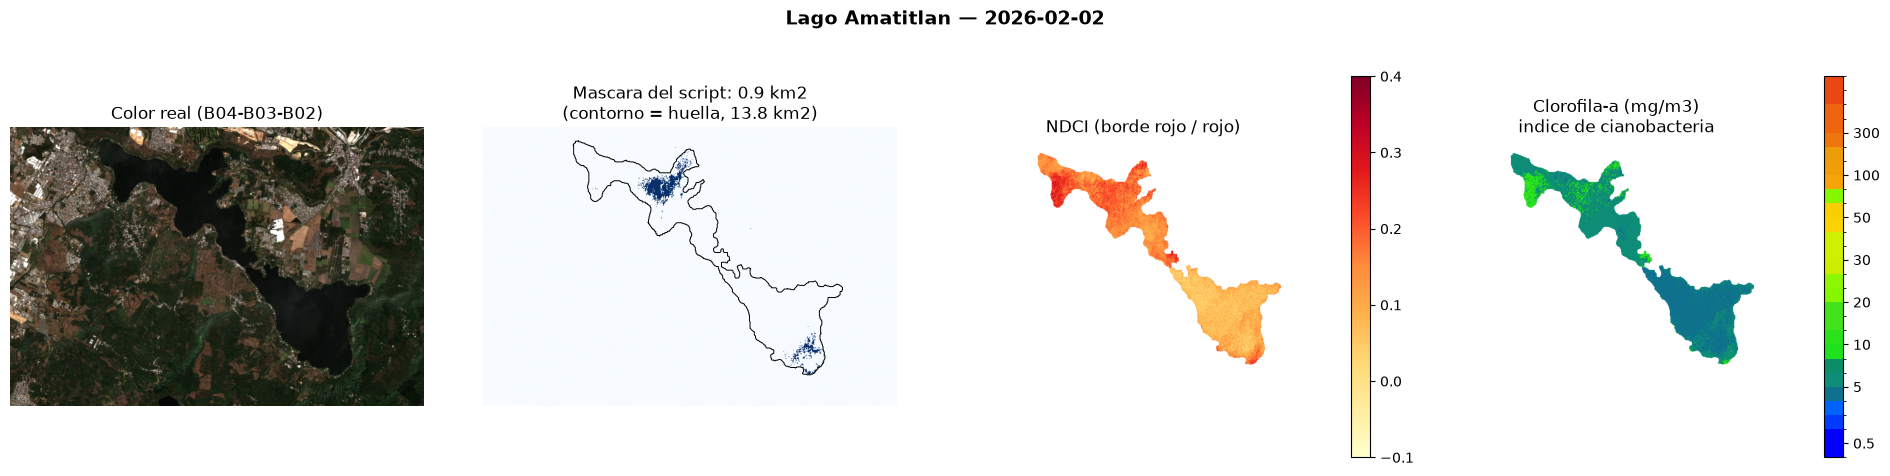

Amatitlan — fecha de mayor floracion: 2026-06-19 (60.2 mg/m3)


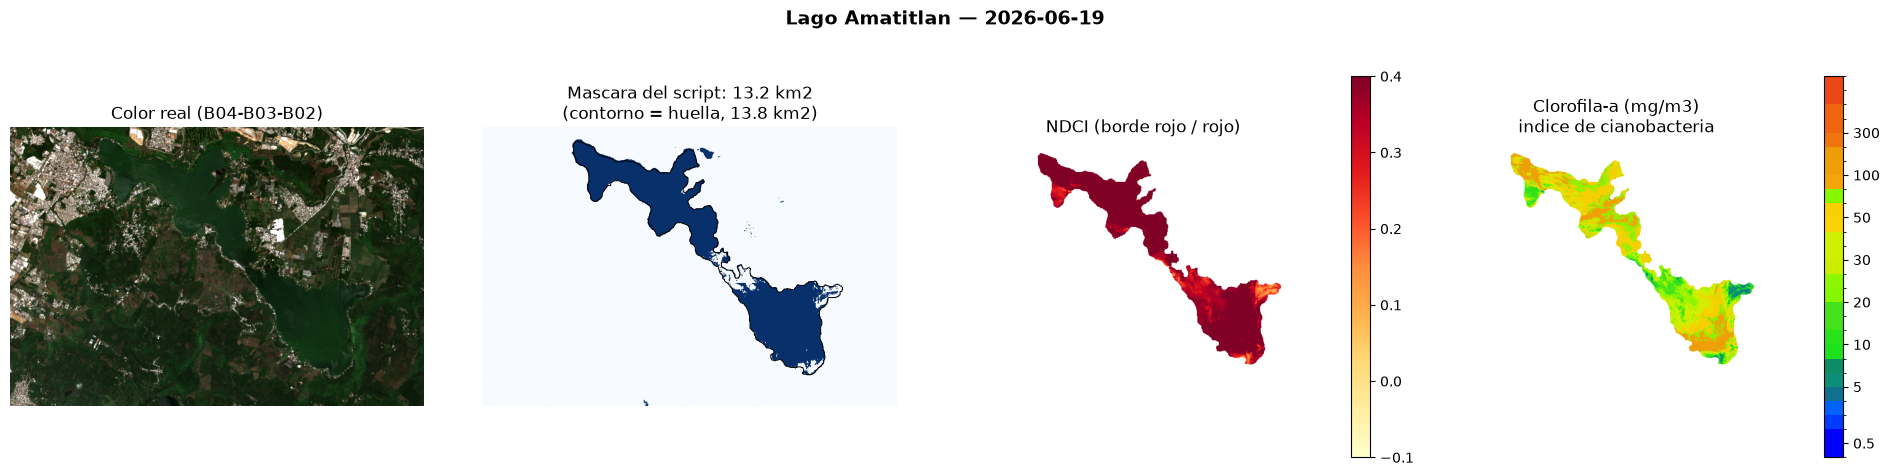

Atitlan — fecha mas limpia: 2025-12-29 (2.5 mg/m3)


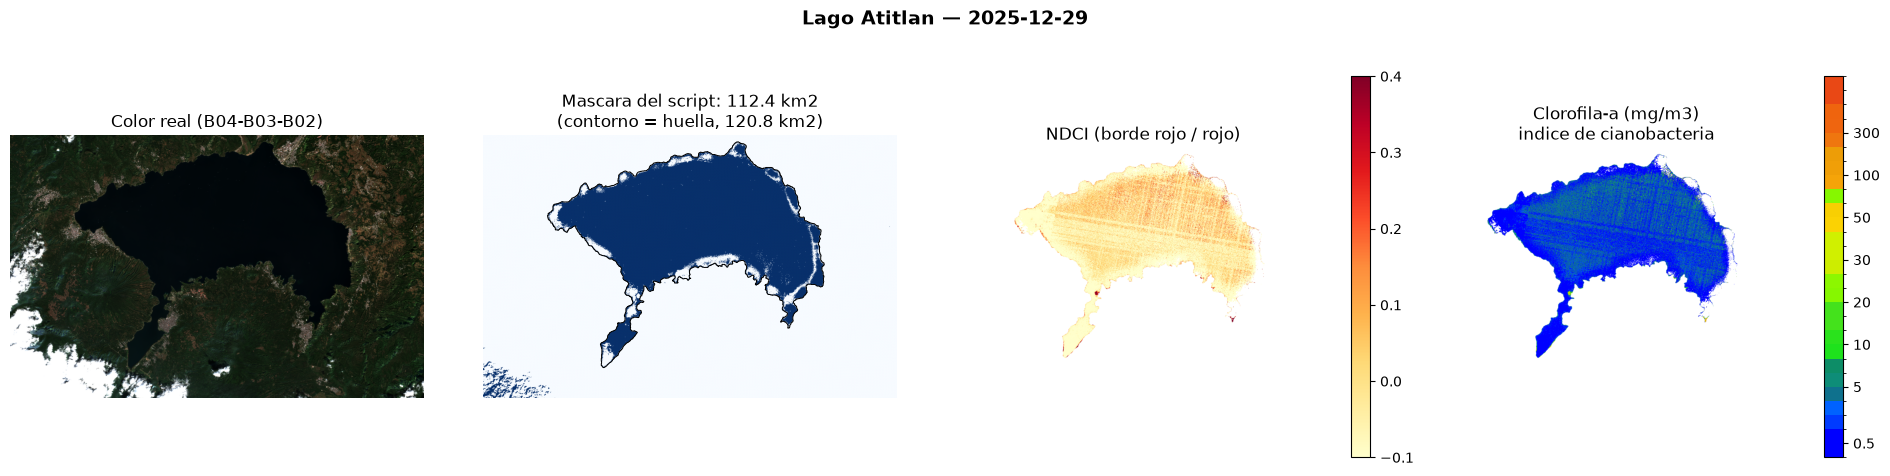

Atitlan — fecha de mayor floracion: 2026-07-22 (4.0 mg/m3)


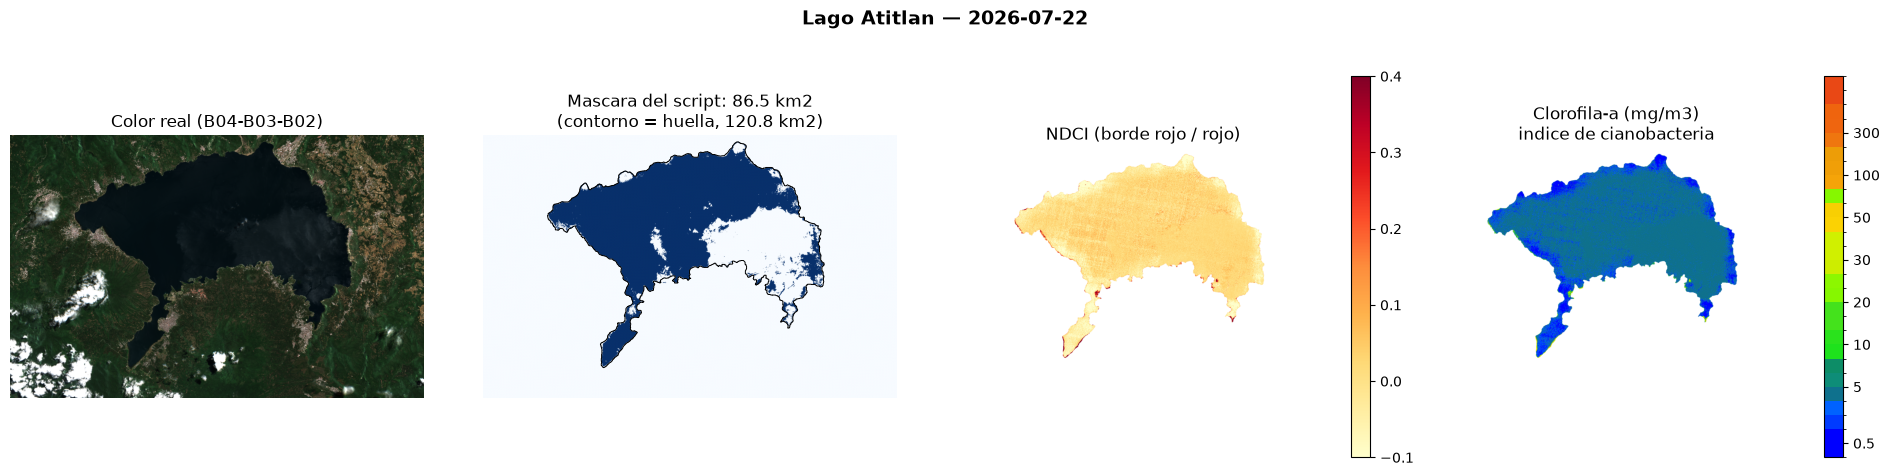

In [12]:
# Para cada lago: la fecha mas limpia y la de mayor floracion, entre las fechas confiables
for nombre, df_lago in [("amatitlan", df_amatitlan), ("atitlan", df_atitlan)]:
    fiable = df_lago[df_lago["Confiable"]]
    for etiqueta, idx in [("fecha mas limpia", fiable["Chla_media"].idxmin()),
                          ("fecha de mayor floracion", fiable["Chla_media"].idxmax())]:
        fecha = df_lago.loc[idx, "Fecha"].strftime("%Y-%m-%d")
        print(f"{nombre.capitalize()} — {etiqueta}: {fecha} "
              f"({df_lago.loc[idx, 'Chla_media']:.1f} mg/m3)")
        mapa_indices(nombre, fecha)

## 6. Análisis temporal (Ejercicio 4)

Con la clorofila-a promediada sobre el espejo de agua de cada fecha construimos la serie temporal
de cada lago. Marcamos como **pico de floración** toda fecha cuyo promedio supere la media del lago
más una desviación estándar; ese criterio se calcula por lago, porque sus niveles base son muy
distintos y un umbral fijo escondería la dinámica de Atitlán.

In [13]:
fiables = df_indices[df_indices["Confiable"]]
resumen_lagos = fiables.groupby("Lago").agg(
    Fechas=("Fecha", "count"), Chla_media=("Chla_media", "mean"),
    Chla_min=("Chla_media", "min"), Chla_max=("Chla_media", "max"),
    Desv=("Chla_media", "std"), NDCI_medio=("NDCI_medio", "mean"),
    Area_km2=("Area_huella_km2", "first"), Pct_area_alta=("Pct_area_alta", "mean"),
).round(2)
resumen_lagos

,Fechas,Chla_media,Chla_min,Chla_max,Desv,NDCI_medio,Area_km2,Pct_area_alta
Lago,,,,,,,,
amatitlan,11,18.43,5.88,60.20,15.19,0.24,13.77,15.56
atitlan,10,3.48,2.49,3.96,0.46,-0.03,120.77,0.22


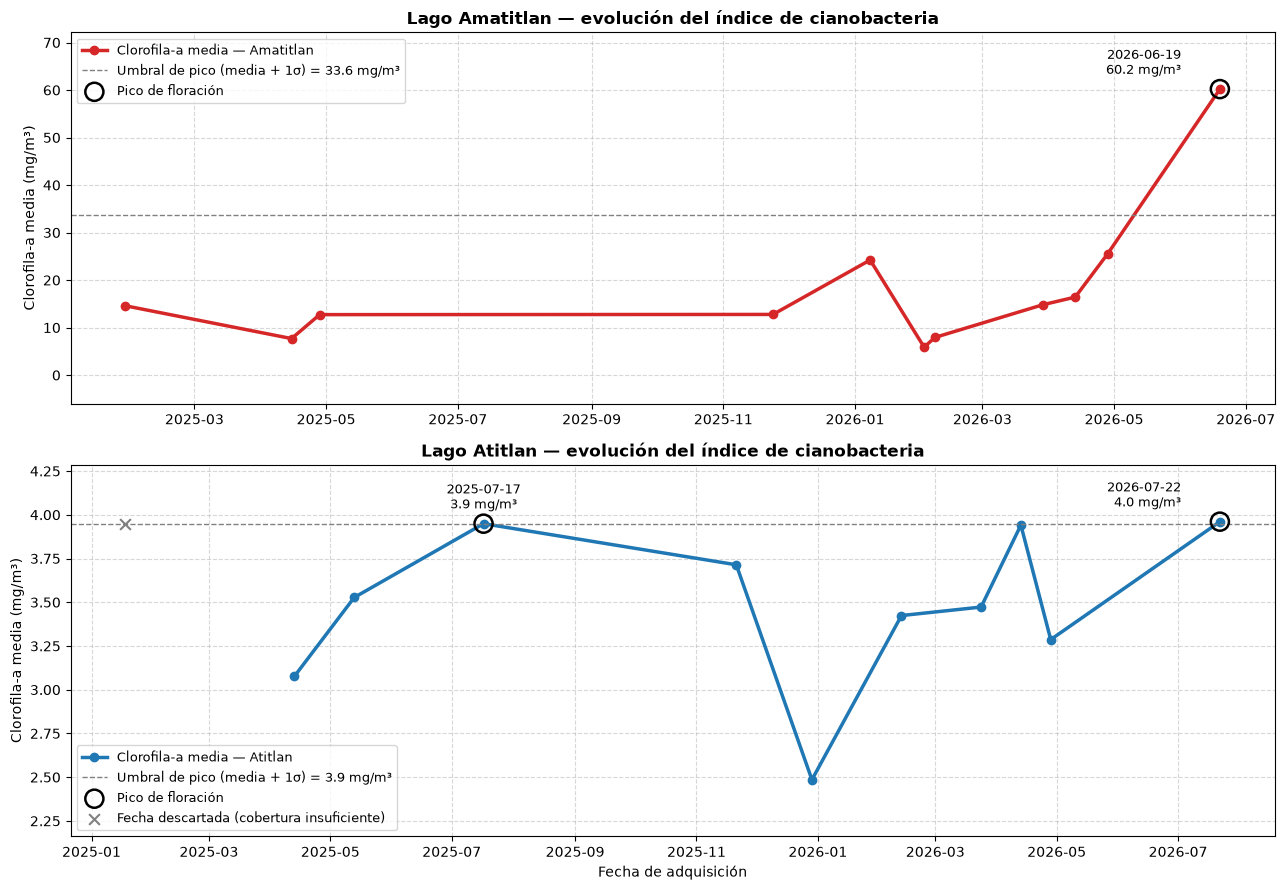

In [14]:
def detectar_picos(df_lago):
    """Picos = fechas confiables por encima de la media del lago mas una desviacion."""
    fiable = df_lago[df_lago["Confiable"]]
    umbral = fiable["Chla_media"].mean() + fiable["Chla_media"].std()
    return fiable[fiable["Chla_media"] >= umbral], umbral


fig, ejes = plt.subplots(2, 1, figsize=(13, 9))
picos = {}

for eje, (nombre, df_lago) in zip(ejes, [("amatitlan", df_amatitlan), ("atitlan", df_atitlan)]):
    color = LAGOS[nombre]["color"]
    fiable = df_lago[df_lago["Confiable"]]
    descartada = df_lago[~df_lago["Confiable"]]
    df_pico, umbral = detectar_picos(df_lago)
    picos[nombre] = df_pico

    eje.plot(fiable["Fecha"], fiable["Chla_media"], marker="o", color=color, linewidth=2.5,
             label=f"Clorofila-a media — {nombre.capitalize()}")
    eje.axhline(umbral, color="grey", linestyle="--", linewidth=1,
                label=f"Umbral de pico (media + 1σ) = {umbral:.1f} mg/m³")
    eje.scatter(df_pico["Fecha"], df_pico["Chla_media"], s=170, facecolors="none",
                edgecolors="black", linewidths=1.8, zorder=5, label="Pico de floración")
    if not descartada.empty:
        eje.scatter(descartada["Fecha"], [umbral] * len(descartada), marker="x", s=60,
                    color="grey", label="Fecha descartada (cobertura insuficiente)")

    eje.margins(y=0.22)  # aire suficiente para que las etiquetas no choquen con el titulo
    for _, fila in df_pico.iterrows():
        # los picos al borde derecho se etiquetan hacia adentro para no salirse del eje
        ultimo = fila["Fecha"] == fiable["Fecha"].max()
        eje.annotate(f"{fila['Fecha']:%Y-%m-%d}\n{fila['Chla_media']:.1f} mg/m³",
                     (fila["Fecha"], fila["Chla_media"]), textcoords="offset points",
                     xytext=(-28 if ultimo else 0, 11), ha="right" if ultimo else "center",
                     fontsize=9)

    eje.set_title(f"Lago {nombre.capitalize()} — evolución del índice de cianobacteria",
                  fontweight="bold")
    eje.set_ylabel("Clorofila-a media (mg/m³)")
    eje.grid(True, linestyle="--", alpha=0.5)
    eje.legend(fontsize=9)

ejes[-1].set_xlabel("Fecha de adquisición")
plt.tight_layout()
plt.show()

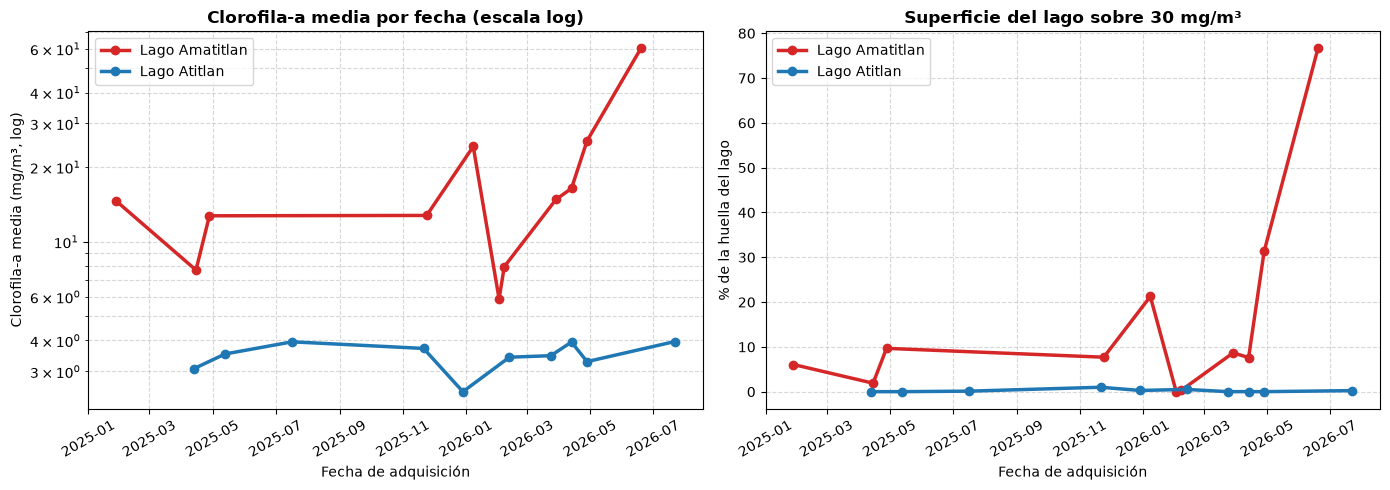

In [15]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, df_lago in [("amatitlan", df_amatitlan), ("atitlan", df_atitlan)]:
    fiable = df_lago[df_lago["Confiable"]]
    ejes[0].plot(fiable["Fecha"], fiable["Chla_media"], marker="o", linewidth=2.5,
                 color=LAGOS[nombre]["color"], label=f"Lago {nombre.capitalize()}")
    ejes[1].plot(fiable["Fecha"], fiable["Pct_area_alta"], marker="o", linewidth=2.5,
                 color=LAGOS[nombre]["color"], label=f"Lago {nombre.capitalize()}")

ejes[0].set_yscale("log")
ejes[0].set_title("Clorofila-a media por fecha (escala log)", fontweight="bold")
ejes[0].set_ylabel("Clorofila-a media (mg/m³, log)")
ejes[1].set_title(f"Superficie del lago sobre {UMBRAL_ALTO:.0f} mg/m³", fontweight="bold")
ejes[1].set_ylabel("% de la huella del lago")
for eje in ejes:
    eje.set_xlabel("Fecha de adquisición")
    eje.grid(True, which="both", linestyle="--", alpha=0.5)
    eje.legend()
    eje.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [16]:
# Fechas criticas: picos detectados por lago, con su contexto
criticas = pd.concat(picos.values()).sort_values(["Lago", "Fecha"])
criticas[["Lago", "Fecha", "Chla_media", "Chla_p90", "Chla_max", "Pct_area_alta",
          "Pct_nata_flotante", "Pct_huella_valida", "Nubosidad_pct"]].round(2)

,Lago,Fecha,Chla_media,Chla_p90,Chla_max,Pct_area_alta,Pct_nata_flotante,Pct_huella_valida,Nubosidad_pct
10,amatitlan,2026-06-19,60.20,103.10,251.12,76.61,0.39,100.00,13.00
3,atitlan,2025-07-17,3.95,4.83,334.95,0.13,0.03,99.97,3.57
10,atitlan,2026-07-22,3.96,4.74,122.92,0.24,0.06,100.00,4.02


In [17]:
# Tipo de floracion: mediana/media cercano a 1 = subida pareja en todo el lago;
# muy por debajo de 1 = manchas localizadas que arrastran el promedio.
tipologia = fiables.assign(
    Razon_mediana_media=(fiables["Chla_mediana"] / fiables["Chla_media"]).round(2),
    Tipo=np.where(fiables["Chla_mediana"] / fiables["Chla_media"] > 0.8,
                  "uniforme", "en parches"),
)
tipologia[["Lago", "Fecha", "Chla_media", "Chla_mediana", "Razon_mediana_media", "Tipo",
           "Pct_area_alta"]].sort_values(["Lago", "Chla_media"]).round(2)

,Lago,Fecha,Chla_media,Chla_mediana,Razon_mediana_media,Tipo,Pct_area_alta
5,amatitlan,2026-02-02,5.88,5.24,0.89,uniforme,0.00
1,amatitlan,2025-04-15,7.69,5.02,0.65,en parches,1.90
6,amatitlan,2026-02-07,7.93,6.91,0.87,uniforme,0.32
2,amatitlan,2025-04-28,12.73,5.83,0.46,en parches,9.68
3,amatitlan,2025-11-24,12.77,6.48,0.51,en parches,7.70
0,amatitlan,2025-01-28,14.59,12.29,0.84,uniforme,6.07
7,amatitlan,2026-03-29,14.81,10.22,0.69,en parches,8.67
8,amatitlan,2026-04-13,16.42,14.08,0.86,uniforme,7.63
4,amatitlan,2026-01-08,24.23,15.62,0.64,en parches,21.26
9,amatitlan,2026-04-28,25.52,10.40,0.41,en parches,31.31


In [18]:
# Estacionalidad: epoca seca (nov-abr) vs lluviosa (may-oct) en Guatemala
estaciones = fiables.assign(
    Estacion=np.where(fiables["Fecha"].dt.month.isin([5, 6, 7, 8, 9, 10]), "lluviosa", "seca")
)
resumen_estacional = estaciones.groupby(["Lago", "Estacion"]).agg(
    Fechas=("Chla_media", "size"), Chla_media=("Chla_media", "mean"),
    Pct_area_alta=("Pct_area_alta", "mean"),
).round(2)
print("Atencion: Amatitlan solo tiene 1 fecha de epoca lluviosa, asi que esa media no es "
      "una estimacion estacional sino una sola observacion.")
resumen_estacional

Atencion: Amatitlan solo tiene 1 fecha de epoca lluviosa, asi que esa media no es una estimacion estacional sino una sola observacion.


Fechas  Chla_media  Pct_area_alta
Lago      Estacion                                   
amatitlan lluviosa       1       60.20          76.61
          seca          10       14.26           9.45
atitlan   lluviosa       3        3.81           0.13
          seca           7        3.34           0.26

## 7. Interpretación de los patrones temporales (Ejercicio 4.3 y 4.4)

### 7.1 Amatitlán: eutrofia crónica con un pico agudo

Las 11 fechas dan una media de **18.4 mg/m³** con desviación de 15.2, entre 5.9 (2026-02-02) y
**60.2 mg/m³ (2026-06-19)** — un rango de 10× dentro del mismo lago. El nivel de fondo nunca baja de
5.9 mg/m³: no hay ninguna fecha en que Amatitlán se vea limpio. En promedio, el **15.6 % de su
superficie** supera los 30 mg/m³.

El criterio media + 1σ (33.6 mg/m³) marca **una sola fecha crítica: 2026-06-19**, con 60.2 mg/m³ de
promedio y el **76.6 % del lago (10.6 de 13.8 km²)** por encima de 30 mg/m³. Le siguen, sin cruzar el
umbral, 2026-04-28 (25.5 mg/m³, 31.3 % del área) y 2026-01-08 (24.2 mg/m³, 21.3 %).

Comparar la mediana con la media distingue dos tipos de evento. En 2026-06-19 la razón es **0.98**:
la clorofila sube de forma pareja en todo el espejo de agua, una floración de lago completo. En
2026-04-28 (razón 0.41) y 2025-04-28 (0.46) la media se dispara por manchas localizadas mientras la
mayoría del lago sigue relativamente limpio — floraciones en parches, típicamente junto a las
entradas de agua contaminada. El 2026-04-28 es además la fecha con más nata flotante detectada por
el FAI (3.1 % de la superficie).

### 7.2 Atitlán: oligotrofia estable con focos puntuales

Las 10 fechas confiables se mueven en una banda de **3.48 ± 0.46 mg/m³**, entre 2.49 y 3.96: una
variación total de 1.6×, frente al 10× de Amatitlán. En promedio solo el **0.22 % de la superficie**
pasa de 30 mg/m³. A escala de lago, **Atitlán no presenta floraciones en el período estudiado**.

El criterio media + 1σ señala 2025-07-17 (3.95) y 2026-07-22 (3.96), pero superan el umbral por
centésimas: son picos estadísticos dentro del ruido, no eventos ecológicos. Que ambos caigan en
julio es sugerente, aunque con dos observaciones no sostiene una conclusión.

Lo que sí aparece son **focos pequeños e intensos**: en 2025-11-21, 2025-12-29 y 2026-02-12 el
máximo por píxel llega al tope de la escala (500 mg/m³) sobre un fondo limpio, y el 2025-11-21 el
1.0 % del lago (**1.2 km²**) supera los 30 mg/m³. Son eventos localizados —compatibles con las
bahías que reciben descargas— que el promedio de un lago de 120.8 km² diluye por completo. Esto
justifica el análisis espacial: en Atitlán el promedio del lago es la métrica equivocada.

### 7.3 Cuán distintos son los dos lagos

| | Amatitlán | Atitlán | Razón |
|---|---|---|---|
| Clorofila-a media | 18.4 mg/m³ | 3.5 mg/m³ | **5.3×** |
| Máximo por fecha | 60.2 mg/m³ | 4.0 mg/m³ | **15.2×** |
| Superficie sobre 30 mg/m³ | 15.6 % | 0.22 % | **70×** |
| Variación entre fechas | 10.2× | 1.6× | — |
| Superficie del lago | 13.8 km² | 120.8 km² | 0.11× |

La diferencia no es de grado sino de régimen. Amatitlán tiene un noveno de la superficie de Atitlán y
recibe, vía el río Villalobos, el drenaje de buena parte del área metropolitana de la Ciudad de
Guatemala: poco volumen para diluir mucha carga de nutrientes. Atitlán, en una caldera de más de
300 m de profundidad, dispone de un volumen enorme que amortigua los aportes de su cuenca; su
problema se manifiesta localmente, no en el promedio.

### 7.4 Estacionalidad: lo que estos datos permiten afirmar

Separando época seca (nov–abr) de lluviosa (may–oct), Amatitlán promedia 14.3 mg/m³ en seca frente a
60.2 en lluviosa, y Atitlán 3.34 frente a 3.81. La dirección coincide en ambos lagos y es la esperada:
las lluvias lavan suelos agrícolas y arrastran aguas residuales, inyectando fósforo y nitrógeno.

Pero hay que ser explícitos con la limitación: **de las 11 fechas de Amatitlán, solo una cae en época
lluviosa**, y es justamente el pico. Con n = 1 no se puede afirmar estacionalidad — lo correcto es
decir que la única imagen de época lluviosa disponible muestra la floración más intensa del período,
lo cual es consistente con ese mecanismo pero no lo demuestra. En Atitlán, con 3 fechas lluviosas
contra 7 secas, la diferencia de +14 % queda dentro de la dispersión (σ = 0.46). Confirmar el patrón
estacional exigiría un muestreo balanceado a lo largo del año, no las fechas fijadas por el enunciado.

### 7.5 Control de calidad: la fecha que descartamos

**Atitlán 2025-01-18 quedó fuera del análisis.** El script clasifica el 96 % de la huella como agua,
así que no es un problema de detección: es que solo el **23.4 % de los píxeles tiene reflectancia
positiva en el rojo y el borde rojo**. Sobre el agua ultraoscura de la caldera, la corrección
atmosférica de L2A sobre-corrigió hasta dejar valores nulos o negativos, donde el NDCI no está
definido. Sin las salvaguardas de la sección 5 esa imagen habría reportado 30 884 mg/m³ de media y
un máximo de 2×10⁹ — suficiente para arruinar toda la serie temporal de Atitlán.

La otra fecha señalada en el enunciado, **Amatitlán 2026-02-07** (cobertura oficial ~57 %), sí
resultó utilizable: la parte cubierta contiene el lago completo y el 100 % de la huella es evaluable.
Se conserva en la serie, con 7.9 mg/m³.